# One Box vs Two Boxes

Does training one boombox on the gastronorm **and** the green-plastic box hurt it compared with a model trained on one box?

| key | run | trained on | eval splits |
|---|---|---|---|
| `gastro` | `gastro-heads-aux-v2` | gastronorm four_objs, speakers 1,2,3,4,7, 500 ep | gastro only |
| `plastic` | `green-plastic-bb-v1` | green-plastic four_objs, speakers 1,3,5,7, 1000 ep | plastic only |
| `both` | `gastro-plastic-bb-v3` | both captures, speakers 1,3,7 only, 5000 ep (cosine) | gastro + plastic |

All three use the same recipe: boombox, d_model 1024, ce-pixel, 64x64 output, aux heads at the default weights.

**A single-box model has never been run on the other box**, so every split has two bars, not three: the single-box model for that box, and `both`. The single-box bar is blue for gastro splits and orange for plastic splits; `both` is always green.

Read section 2 before trusting any number. The three runs do not see the same speakers or the same number of samples, and `both` may still be training.

**The gastro-only run is underfit** (train IoU 0.53, section 4.1), so on gastro the main comparison flatters `both`. Section 4.1 adds a well-trained gastro-only baseline (`fo-base-v1`, 32x32) and the takeaways use that one.

# 1 Import

In [1]:
import re
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

REPO = Path.cwd().parent
sys.path.insert(0, str(REPO))
from utils.metrics import center_of_mass, contour_f, mass_error, object_centroids, soft_iou
from viz.data import _info_dirs, load_gt

pd.set_option("display.width", 220, "display.max_columns", 80)

RUNS = {"gastro": "gastro-heads-aux-v2", "plastic": "green-plastic-bb-v1", "both": "gastro-plastic-bb-v3"}
EXPS = {"gastro": "2026_09_27_gastronorm_four_objs", "plastic": "2026_10_05_green_plastic_four_objs"}
RENAME = {"one-cube": "cube", "red-cube-lid": "cube-lid"}  # gastro-only split names -> combined names
COLOR = {"gastro": "#2a78d6", "plastic": "#eb6834", "both": "#1baf7a"}
LABEL = {"gastro": "gastro only", "plastic": "plastic only", "both": "both boxes"}

# Held-out positions of an object the model trained on = in distribution. Everything else is a new object
# (or, for cube-shifted-lasers-*, the same cube with the laser grid moved).
ID_SPLITS = ["cube", "vase", "candle", "soap-dispenser", "two-cubes", "cube-vase"]
SETUP_SPLITS = ["cube-shifted-lasers-1", "cube-shifted-lasers-2", "cube-shifted-lasers-3-backside"]
def kind(split):
    if split in ID_SPLITS: return "ID"
    if split in SETUP_SPLITS: return "OOD-setup"
    return "OOD-speaker" if "unseen-speaker" in split else "OOD-object"

plt.rcParams.update({"axes.spines.top": False, "axes.spines.right": False, "axes.grid": True, "grid.alpha": 0.25,
                     "axes.axisbelow": True, "figure.dpi": 110})
CACHE = REPO / "notebooks" / "runs" / "92_per_sample.parquet"

# 2 What Each Run Saw

The split functions are re-run on the exact mds snapshot each run trained on, so these counts are what the trainer saw.

Two confounds come out of this table:

1. **`both` trains on speakers 1, 3, 7 only.** It has 2772 gastro and 2892 plastic training samples. That is 58% of what `gastro` had (4760, 5 speakers) and 75% of what `plastic` had (3872, 4 speakers). The training *positions* are the same. So any drop for `both` mixes "two boxes" with "fewer speakers per position".
2. **The eval sets differ.** `gastro` evaluates speakers 1,2,3,4,7, `plastic` evaluates 1,3,5,7, and `both` evaluates 1,3,7. A few splits also hold out different positions (gastro `cube`, plastic `vase` and `candle`). Every comparison below uses only the **(position, speaker) samples that both models were scored on**.

In [2]:
import json, collections
import src.model.dataset as D

def index(path, exp=None):
    rows = [json.loads(l) for l in open(path) if l.strip()]
    for r in rows: r.setdefault("experiment", exp)
    return rows

SNAP = {  # mds snapshot each run trained on (by date; the run logs don't print the hash)
    "gastro": (REPO / "experiments" / EXPS["gastro"] / "mds/362bc40959efa943/metadata.jsonl", EXPS["gastro"]),
    "plastic": (REPO / "experiments" / EXPS["plastic"] / "mds/4a51752521e6950f/metadata.jsonl", EXPS["plastic"]),
    "both": (REPO / "experiments" / EXPS["gastro"] / "mds/bb6dfbfa770f3dd9/metadata.jsonl", None),
}
SPLIT_FN = {"gastro": D.gastronorm_four_objs_2, "plastic": D.green_plastic_four_objs, "both": D.gastro_plastic_four_objs}

rows = []
for key, (path, exp) in SNAP.items():
    idx = index(path, exp)
    for label, ids in SPLIT_FN[key]("x", verbose=0, index=idx).items():
        for e in sorted({idx[i]["experiment"] for i in ids}):
            sub = [idx[i] for i in ids if idx[i]["experiment"] == e]
            rows.append(dict(run=key, split=label, box="gastro" if "gastro" in e else "plastic", n=len(sub),
                             positions=len({r["position_id"] for r in sub}),
                             speakers=",".join(map(str, sorted({r["speaker"] for r in sub})))))
seen = pd.DataFrame(rows)
display(seen[seen.split == "train"])

# training samples per object, per run and box
tr_obj = []
for key, (path, exp) in SNAP.items():
    idx = index(path, exp)
    for i in SPLIT_FN[key]("x", verbose=0, index=idx)["train"]:
        r = idx[i]
        tr_obj.append((key, "gastro" if "gastro" in r["experiment"] else "plastic", "+".join(sorted(r.get("objects") or {})) or "(empty)", r["position_id"]))
tr_obj = pd.DataFrame(tr_obj, columns=["run", "box", "objects", "position_id"])
pd.concat({"samples": tr_obj.groupby(["box", "objects", "run"]).size().unstack("run"),
           "positions": tr_obj.groupby(["box", "objects", "run"]).position_id.nunique().unstack("run")}, axis=1).fillna(0).astype(int)

,run,split,box,n,positions,speakers
0,gastro,train,gastro,4760,952,"1,2,3,4,7"
13,plastic,train,plastic,3872,968,"1,3,5,7"
33,both,train,gastro,2772,924,"1,3,7"
34,both,train,plastic,2892,964,"1,3,7"


samples                positions               
run                            both gastro plastic      both gastro plastic
box     objects                                                            
gastro  (empty)                  36     60       0        12     12       0
        candle                  624   1040       0       208    208       0
        green-cube+red-cube     174    290       0        58     58       0
        red-cube                591   1125       0       197    225       0
        red-cube+vase           117    195       0        39     39       0
        soap dispenser          588    980       0       196    196       0
        vase                    642   1070       0       214    214       0
plastic (empty)                  45      0      60        15      0      15
        candle                  606      0     812       202      0     203
        green-cube+red-cube     192      0     256        64      0      64
        red-cube                606      0     808       202      0     202
        red-cube+vase           117      0     156        39      0      39
        soap dispenser          711      0     948       237      0     237
        vase                    615      0     832       205      0     208

# 3 Load Per-Sample Predictions

Every run saved its eval-set masks to `outputs_history/eval/<split>/ep<NNNN>-*.pt`. Each one is joined to its 64x64 target on the sample dir name and scored here:

- `iou`: soft IoU, same as the logged metric (checked: plastic/candle recomputes to 0.7574 vs logged 0.7574).
- `mass`: symmetric mass error in [-1, 1]. Negative means the model paints too little.
- `com_px`: distance between predicted and target centre of mass, in 64-grid cells.
- `n_pred`: blobs in the thresholded prediction, against `n_true` objects. `count_ok` is an exact match.
- `fuzz`: of the pixels the model paints at all (p > 0.1), the fraction it is unsure about (0.1 < p < 0.9). Higher means a blurrier, less committed mask.
- `contour`: boundary F-score at 1 cell tolerance.

`both` is scored at three epochs: **500** (each gastro sample seen as often as in `gastro`), **1000** (same for `plastic`), and its **latest** saved epoch. `both` uses a 5000-epoch cosine schedule, so ep500 and ep1000 are mid-schedule at high learning rate, while the single-box runs are fully annealed. That makes the matched-epoch rows pessimistic for `both`.

In [3]:
GT = {box: load_gt(REPO / "experiments" / e, 64, 64) for box, e in EXPS.items()}

def eval_dirs(key):
    root = REPO / "runs" / RUNS[key] / "outputs_history" / "eval"
    for d in sorted(root.iterdir()):
        if d.name in EXPS:  # combined run: eval/<box>/<split>
            for s in sorted(d.iterdir()): yield d.name, s.name, s
        else: yield key, RENAME.get(d.name, d.name), d

def epochs(d): return sorted({int(f.name[2:6]) for f in d.glob("ep*.pt")})

def score(key, box, split, d, epoch):
    preds, info = [], {k: [] for k in ("sid", "position_id", "speaker", "n_true")}
    for f in sorted(d.glob(f"ep{epoch:04d}-*.pt")):
        x = torch.load(f, weights_only=False)
        preds.append(x["mask_pred"].float())
        info["sid"] += list(_info_dirs(x["info"]))
        info["position_id"] += x["info"]["position_id"].tolist()
        info["speaker"] += x["info"]["speaker"].tolist()
        info["n_true"] += x["info"]["n_objects"].tolist()
    if not preds: return None, None
    p, gt = torch.cat(preds), GT[box]
    keep = np.array([s in gt.row_of for s in info["sid"]])  # gastro-only predates the removal of 126 bad samples
    p, info = p[torch.from_numpy(keep)], {k: list(np.asarray(v)[keep]) for k, v in info.items()}
    t = torch.from_numpy(np.stack([gt.masks[gt.row_of[s]] for s in info["sid"]]))
    cp, ct = center_of_mass(p, normalize=False), center_of_mass(t, normalize=False)
    painted = (p > 0.1).sum((-2, -1)).clamp(min=1)
    df = pd.DataFrame(dict(run=key, box=box, split=split, kind=kind(split), epoch=epoch, **info,
        iou=soft_iou(p, t).numpy(), mass=mass_error(p, t).numpy(), com_px=(cp - ct).norm(dim=-1).numpy(),
        n_pred=[len(c) for c in object_centroids(p)], contour=contour_f(p, t).numpy(),
        fuzz=(((p > 0.1) & (p < 0.9)).sum((-2, -1)) / painted).numpy(), peak=p.amax((-2, -1)).numpy()))
    df["count_ok"] = df.n_pred == df.n_true
    return df, p.half().numpy()

def both_epochs():
    e = epochs(next(d for _, _, d in eval_dirs("both")))
    return {"both@500": 500, "both@1000": 1000, "both": e[-1]}

ARMS = {"gastro": ("gastro", 500), "plastic": ("plastic", 1000), **{a: ("both", e) for a, e in both_epochs().items()}}
LATEST = ARMS["both"][1]
print({a: e for a, (_, e) in ARMS.items()})

MASKS = {}  # (arm, box, sid) -> fp16 prediction, for the gallery in section 9
frames = []
for arm, (key, ep) in ARMS.items():
    for box, split, d in eval_dirs(key):
        df, p = score(key, box, split, d, ep)
        if df is None: continue
        frames.append(df.assign(arm=arm))
        MASKS.update({(arm, box, s): m for s, m in zip(df.sid, p)})
per = pd.concat(frames, ignore_index=True)
per.to_parquet(CACHE)
per.groupby("arm").size()

{'gastro': 500, 'plastic': 1000, 'both@500': 500, 'both@1000': 1000, 'both': 2500}


arm
both         2351
both@1000    2351
both@500     2351
gastro       1400
plastic      1842
dtype: int64

Keep only samples that the single-box model **and** `both` were scored on. Splits that exist in only one run (`cube-unseen-speaker-*`, `cube-lid` vs `red-cube-lid` is renamed above) drop out here.

In [4]:
single = per[per.arm.isin(["gastro", "plastic"])]
keys = ["box", "split", "position_id", "speaker"]
common = single[keys].merge(per[per.arm == "both"][keys]).drop_duplicates()
cmp = per.merge(common, on=keys)
SPLITS = {b: [s for s in ID_SPLITS + sorted(set(cmp[cmp.box == b].split) - set(ID_SPLITS), key=lambda s: (kind(s), s))
              if s in set(cmp[cmp.box == b].split)] for b in EXPS}
print("samples per arm on the shared set:", cmp.groupby("arm").size().to_dict())
pd.crosstab([cmp.box, cmp.split], cmp.arm).loc[[(b, s) for b in EXPS for s in SPLITS[b]]]

samples per arm on the shared set: {'both': 1887, 'both@1000': 1887, 'both@500': 1887, 'gastro': 699, 'plastic': 1188}


arm                                     both  both@1000  both@500  gastro  plastic
box     split                                                                     
gastro  cube                              30         30        30      30        0
        vase                             162        162       162     162        0
        candle                           156        156       156     156        0
        soap-dispenser                   147        147       147     147        0
        two-cubes                         42         42        42      42        0
        cube-vase                         30         30        30      30        0
        coffee-pot                        24         24        24      24        0
        cube-lid                          30         30        30      30        0
        cylinder-1000g                    27         27        27      27        0
        cylinder-100g                      6          6         6       6        0
        cylinder-500g                     27         27        27      27        0
        soap-dispenser-sideways           18         18        18      18        0
plastic cube                             150        150       150       0      150
        vase                              27         27        27       0       27
        candle                            72         72        72       0       72
        soap-dispenser                   176        176       176       0      176
        two-cubes                         48         48        48       0       48
        cube-vase                         30         30        30       0       30
        coffee-pot                       258        258       258       0      258
        cube-lid                          48         48        48       0       48
        cylinder-1000g                    24         24        24       0       24
        cylinder-100g                     21         21        21       0       21
        cylinder-200g                     27         27        27       0       27
        cylinder-500g                     24         24        24       0       24
        portable-charger                  30         30        30       0       30
        soap-dispenser-sideways           21         21        21       0       21
        cube-shifted-lasers-1             24         24        24       0       24
        cube-shifted-lasers-2             24         24        24       0       24
        cube-shifted-lasers-3-backside    24         24        24       0       24
        cube-unseen-speaker-baseline     120        120       120       0      120
        cube-unseen-speaker-unseen        40         40        40       0       40

# 4 IoU Per Split

One panel per box. In-distribution splits come first, then new objects, then shifted lasers. Error bars are 95% bootstrap intervals over positions (speakers at one position share a target, so they are not independent).

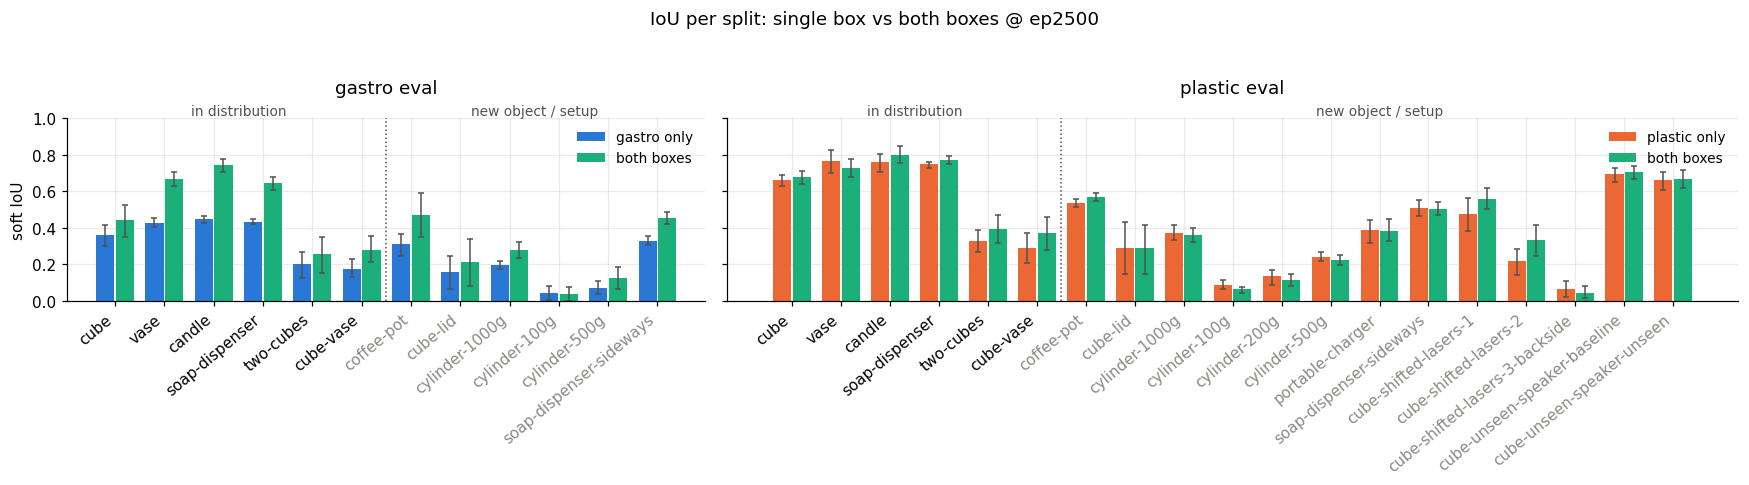

In [5]:
rng = np.random.default_rng(0)

def boot(df, col, n=500):
    g = df.groupby("position_id")[col].mean().to_numpy()
    if len(g) < 2: return np.nan, np.nan
    m = rng.choice(g, (n, len(g))).mean(1)
    return np.percentile(m, 2.5), np.percentile(m, 97.5)

def split_bars(metric, arms=("single", "both"), ylabel=None, ylim=None, title=None):
    fig, axes = plt.subplots(1, 2, figsize=(16, 4.2), gridspec_kw={"width_ratios": [len(SPLITS[b]) for b in EXPS]}, sharey=True)
    for ax, box in zip(axes, EXPS):
        names = [box if a == "single" else a for a in arms]
        w = 0.8 / len(names)
        for j, a in enumerate(names):
            sub = cmp[(cmp.arm == a) & (cmp.box == box)]
            x = np.arange(len(SPLITS[box])) + (j - (len(names) - 1) / 2) * w
            m = [sub[sub.split == s][metric].mean() for s in SPLITS[box]]
            ci = np.array([boot(sub[sub.split == s], metric) for s in SPLITS[box]]).T
            c = COLOR.get(a, COLOR["both"])
            ax.bar(x, m, w * 0.92, color=c, alpha=1.0 if a in (box, "both") else 0.45, label=LABEL.get(a, a))
            ax.errorbar(x, m, yerr=[np.subtract(m, ci[0]), np.subtract(ci[1], m)], fmt="none", ecolor="#52514e", lw=1, capsize=2)
        ax.set_xticks(range(len(SPLITS[box])), SPLITS[box], rotation=40, ha="right")
        for i, s in enumerate(SPLITS[box]):
            if kind(s) != "ID": ax.get_xticklabels()[i].set_color("#8a8984")
        n_id = sum(kind(s) == "ID" for s in SPLITS[box])
        ax.axvline(n_id - 0.5, color="#52514e", lw=1, ls=":")
        ax.text(n_id / 2 - 0.5, 1.0, "in distribution", transform=ax.get_xaxis_transform(), ha="center", va="bottom", fontsize=9, color="#52514e")
        ax.text((n_id + len(SPLITS[box])) / 2 - 0.5, 1.0, "new object / setup", transform=ax.get_xaxis_transform(), ha="center", va="bottom", fontsize=9, color="#52514e")
        ax.set_title(f"{box} eval", pad=16)
        ax.legend(frameon=False, fontsize=9, loc="upper right")
        if ylim: ax.set_ylim(*ylim)
    axes[0].set_ylabel(ylabel or metric)
    if title: fig.suptitle(title, y=1.04)
    fig.tight_layout()
    plt.show()

split_bars("iou", ylabel="soft IoU", ylim=(0, 1), title=f"IoU per split: single box vs both boxes @ ep{LATEST}")

The same thing as a difference, so small shifts are readable. Each dot is `both - single` for one split, sized by its number of positions. Points left of zero are splits where training on two boxes hurt.

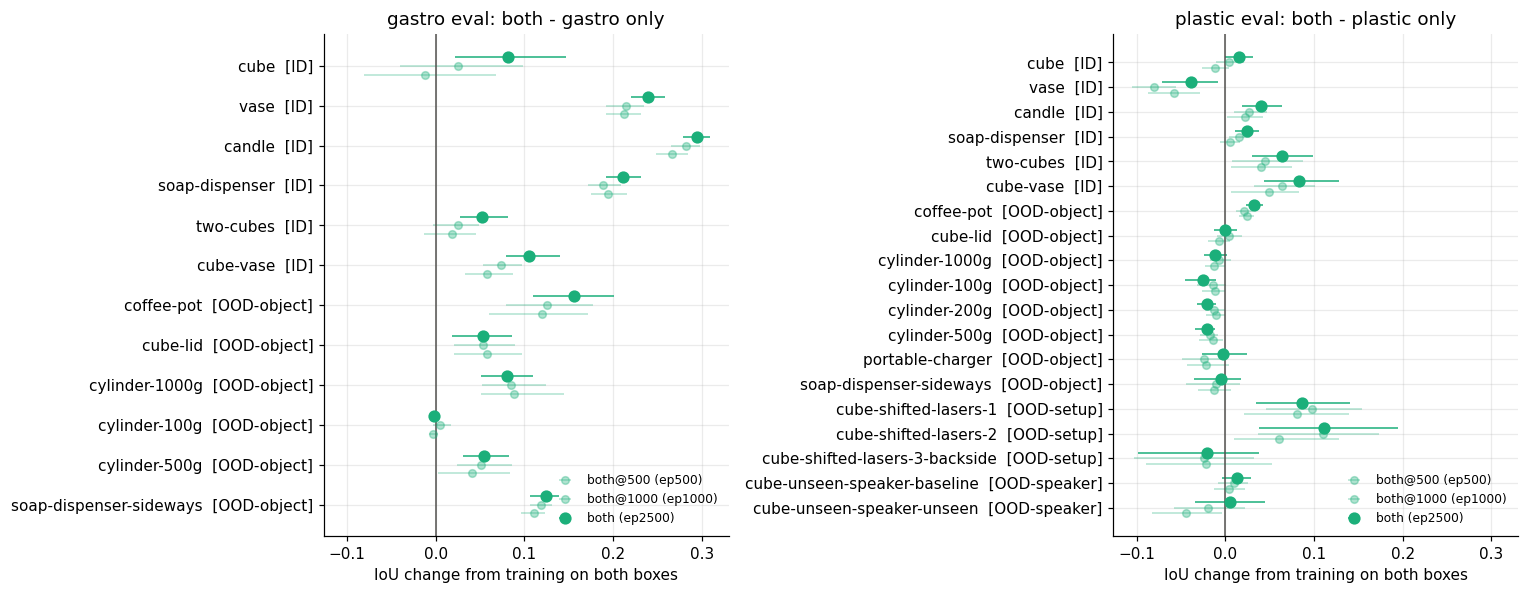

,box,split,d,n,lo,hi,kind
0,gastro,candle,0.295,52,0.277,0.309,ID
1,gastro,coffee-pot,0.156,8,0.113,0.199,OOD-object
2,gastro,cube,0.081,10,0.008,0.151,ID
3,gastro,cube-lid,0.053,10,0.019,0.088,OOD-object
4,gastro,cube-vase,0.105,10,0.074,0.136,ID
5,gastro,cylinder-1000g,0.080,9,0.045,0.110,OOD-object
6,gastro,cylinder-100g,-0.002,2,-0.007,0.002,OOD-object
7,gastro,cylinder-500g,0.055,9,0.027,0.080,OOD-object
8,gastro,soap-dispenser,0.212,49,0.193,0.230,ID
9,gastro,soap-dispenser-sideways,0.124,6,0.105,0.138,OOD-object


In [6]:
def deltas(metric, arm="both"):
    a = cmp[cmp.arm == arm].groupby(keys)[metric].mean()
    s = cmp[cmp.arm.isin(["gastro", "plastic"])].groupby(keys)[metric].mean()
    d = (a - s).rename("d").reset_index().dropna()
    return d.groupby(["box", "split"]).agg(d=("d", "mean"), n=("position_id", "nunique"),
                                         lo=("d", lambda v: np.percentile(rng.choice(v, (300, len(v))).mean(1), 2.5)),
                                         hi=("d", lambda v: np.percentile(rng.choice(v, (300, len(v))).mean(1), 97.5))).reset_index()

def delta_plot(metric, xlabel, arms=("both@500", "both@1000", "both")):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5.5), sharex=True)
    for ax, box in zip(axes, EXPS):
        order = SPLITS[box][::-1]
        for j, arm in enumerate(arms):
            d = deltas(metric, arm).set_index(["box", "split"]).loc[box].reindex(order)
            y = np.arange(len(order)) + (j - 1) * 0.22
            final = arm == "both"
            ax.errorbar(d.d, y, xerr=[d.d - d.lo, d.hi - d.d], fmt="o", ms=7 if final else 5, color=COLOR["both"],
                        alpha=1 if final else 0.35, ecolor=COLOR["both"], elinewidth=1, label=f"{arm} (ep{ARMS[arm][1]})")
        ax.axvline(0, color="#52514e", lw=1)
        ax.set_yticks(range(len(order)), [f"{s}  [{kind(s)}]" for s in order])
        ax.set_title(f"{box} eval: both - {box} only")
        ax.set_xlabel(xlabel)
        ax.legend(frameon=False, fontsize=8, loc="lower right")
    fig.tight_layout()
    plt.show()

delta_plot("iou", "IoU change from training on both boxes")
deltas("iou").assign(kind=lambda d: d.split.map(kind)).round(3)

## 4.1 The gastro-only run is underfit, so use a second gastro baseline

`gastro-heads-aux-v2` ends at **train IoU 0.53** and its masks never go above ~0.53 probability (`peak` in section 6). Every 64x64 gastro-only run from that week stalls the same way at 500 epochs (`gastro-res64-v1`, the whole heads sweep), while the 32x32 run reaches 0.94 in the same number of steps. It has not finished learning, so the big gastro gains above mostly show "trained longer", not "trained on two boxes".

A well-trained gastro-only model exists at 32x32: **`fo-base-v1`** (same capture and `gastronorm_four_objs_2` split, 9000 steps at batch 256, train IoU 0.975). To compare fairly, the `both` 64x64 masks are 2x2 average-pooled to 32x32 and both models are scored against the 32x32 targets. Pooling barely changes a mask: the pooled 64x64 targets match the 32x32 targets at soft IoU 0.994.

fo-base-v1 @ep500 vs both @ep2500, 699 shared samples


arm                                 both, pooled to 32  gastro 32 (fo-base-v1)  both - gastro
kind       split                                                                             
ID         candle                                0.744                   0.759         -0.015
           cube                                  0.454                   0.522         -0.068
           cube-vase                             0.285                   0.323         -0.039
           soap-dispenser                        0.654                   0.659         -0.005
           two-cubes                             0.266                   0.335         -0.070
           vase                                  0.671                   0.699         -0.028
OOD-object coffee-pot                            0.473                   0.486         -0.013
           cube-lid                              0.215                   0.249         -0.034
           cylinder-1000g                        0.280                   0.244          0.035
           cylinder-100g                         0.040                   0.048         -0.008
           cylinder-500g                         0.131                   0.136         -0.004
           soap-dispenser-sideways               0.462                   0.458          0.004

arm,"both, pooled to 32",gastro 32 (fo-base-v1),both - gastro
kind,,,
ID,0.512,0.55,-0.038
OOD-object,0.267,0.27,-0.003


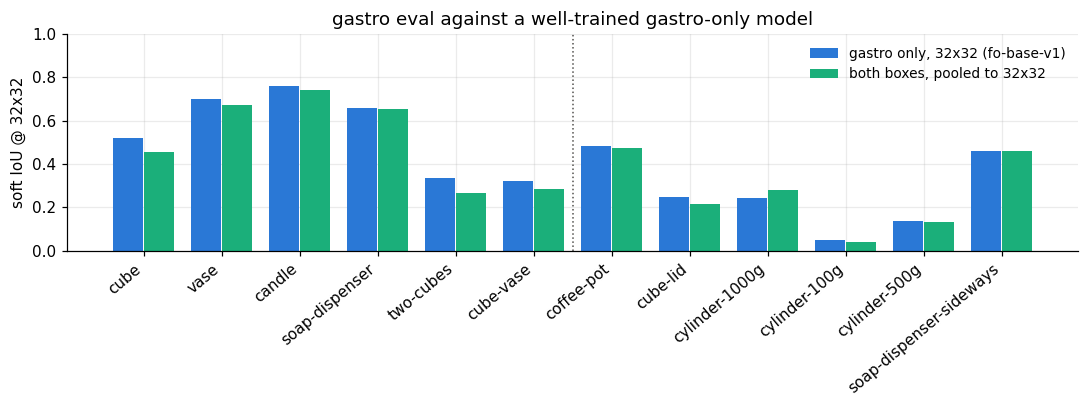

In [7]:
GT32 = load_gt(REPO / "experiments" / EXPS["gastro"], 32, 32)

def score32(run, sub, epoch, split, arm):
    preds, sid, pos, spk = [], [], [], []
    for f in sorted((REPO / "runs" / run / "outputs_history" / "eval" / sub).glob(f"ep{epoch:04d}-*.pt")):
        x = torch.load(f, weights_only=False)
        preds.append(x["mask_pred"].float()); sid += list(_info_dirs(x["info"]))
        pos += x["info"]["position_id"].tolist(); spk += x["info"]["speaker"].tolist()
    p = torch.cat(preds)
    if p.shape[-1] == 64: p = torch.nn.functional.avg_pool2d(p[:, None], 2)[:, 0]
    keep = [i for i, s in enumerate(sid) if s in GT32.row_of]
    p, sid = p[keep], [sid[i] for i in keep]
    t = torch.from_numpy(np.stack([GT32.masks[GT32.row_of[s]] for s in sid]))
    return pd.DataFrame(dict(arm=arm, split=split, kind=kind(split), position_id=np.array(pos)[keep], speaker=np.array(spk)[keep],
                             iou=soft_iou(p, t).numpy(), mass=mass_error(p, t).numpy()))

fo = REPO / "runs" / "fo-base-v1" / "outputs_history" / "eval"
fo_ep = epochs(fo / "candle")[-1]
g32 = pd.concat([score32("fo-base-v1", d.name, fo_ep, RENAME.get(d.name, d.name), "gastro 32 (fo-base-v1)") for d in sorted(fo.iterdir())] +
                [score32(RUNS["both"], f"gastro/{s}", LATEST, s, "both, pooled to 32") for s in SPLITS["gastro"]])
k32 = ["split", "position_id", "speaker"]
shared = g32[g32.arm.str.startswith("gastro")][k32].merge(g32[g32.arm.str.startswith("both")][k32])
g32 = g32.merge(shared, on=k32)
t32 = g32.groupby(["kind", "split", "arm"]).iou.mean().unstack("arm")
t32["both - gastro"] = t32.iloc[:, 0] - t32.iloc[:, 1]
print(f"fo-base-v1 @ep{fo_ep} vs both @ep{LATEST}, {len(shared)} shared samples")
display(t32.round(3))
display(t32.groupby(level="kind").mean().round(3))

fig, ax = plt.subplots(figsize=(10, 3.8))
order = SPLITS["gastro"]
m = g32.groupby(["split", "arm"]).iou.mean().unstack().reindex(order)
x = np.arange(len(order))
ax.bar(x - 0.2, m.iloc[:, 1], 0.38, color=COLOR["gastro"], label="gastro only, 32x32 (fo-base-v1)")
ax.bar(x + 0.2, m.iloc[:, 0], 0.38, color=COLOR["both"], label="both boxes, pooled to 32x32")
ax.set_xticks(x, order, rotation=40, ha="right"); ax.set_ylabel("soft IoU @ 32x32"); ax.set_ylim(0, 1)
ax.axvline(sum(kind(s) == "ID" for s in order) - 0.5, color="#52514e", lw=1, ls=":")
ax.set_title("gastro eval against a well-trained gastro-only model"); ax.legend(frameon=False, fontsize=9)
fig.tight_layout(); plt.show()

# 5 In Distribution vs New Objects

Is the drop concentrated on unseen objects, or is it the same everywhere? Each split is weighted by its positions here, so the big ID splits do not drown the small OOD ones: first average per split, then across splits.

In [8]:
def by_kind(metric):
    m = cmp.groupby(["arm", "box", "kind", "split"])[metric].mean().reset_index()
    m["arm"] = m.arm.where(~m.arm.isin(["gastro", "plastic"]), "single")
    return m.groupby(["box", "kind", "arm"])[metric].mean().unstack("arm")[["single", "both@500", "both@1000", "both"]]

t = by_kind("iou")
t["both - single"] = t["both"] - t["single"]
t["relative"] = t["both - single"] / t["single"]
t.round(3)

arm                  single  both@500  both@1000   both  both - single  relative
box     kind                                                                    
gastro  ID            0.341     0.464      0.476  0.505          0.164     0.481
        OOD-object    0.184     0.253      0.258  0.262          0.078     0.421
plastic ID            0.591     0.599      0.603  0.622          0.031     0.053
        OOD-object    0.319     0.311      0.312  0.312         -0.007    -0.021
        OOD-setup     0.252     0.292      0.313  0.311          0.059     0.234
        OOD-speaker   0.677     0.656      0.672  0.686          0.009     0.014

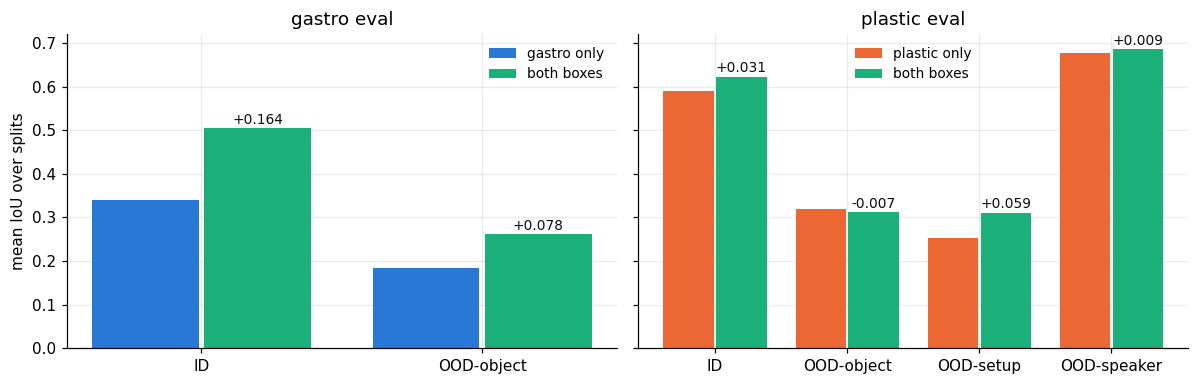

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6), sharey=True)
for ax, box in zip(axes, EXPS):
    tb = t.loc[box]
    x = np.arange(len(tb))
    ax.bar(x - 0.2, tb.single, 0.38, color=COLOR[box], label=LABEL[box])
    ax.bar(x + 0.2, tb.both, 0.38, color=COLOR["both"], label=LABEL["both"])
    for i, (s, b) in enumerate(zip(tb.single, tb.both)):
        ax.text(i + 0.2, b + 0.01, f"{b - s:+.3f}", ha="center", fontsize=9, color="#0b0b0b")
    ax.set_xticks(x, tb.index)
    ax.set_title(f"{box} eval")
    ax.legend(frameon=False, fontsize=9)
axes[0].set_ylabel("mean IoU over splits")
fig.tight_layout(); plt.show()

# 6 The Other Metrics

Same layout as section 4, one figure per metric. What each one asks:

- **`mass`**: does `both` paint less (under-paint, negative) or more than the single-box model?
- **`com_px`**: is it putting the object in the wrong place?
- **`count_ok`**: does the predicted mask have the right number of blobs?
- **`fuzz`**: is the mask less committed, i.e. "more confused"?
- **`contour`**: are the edges worse?

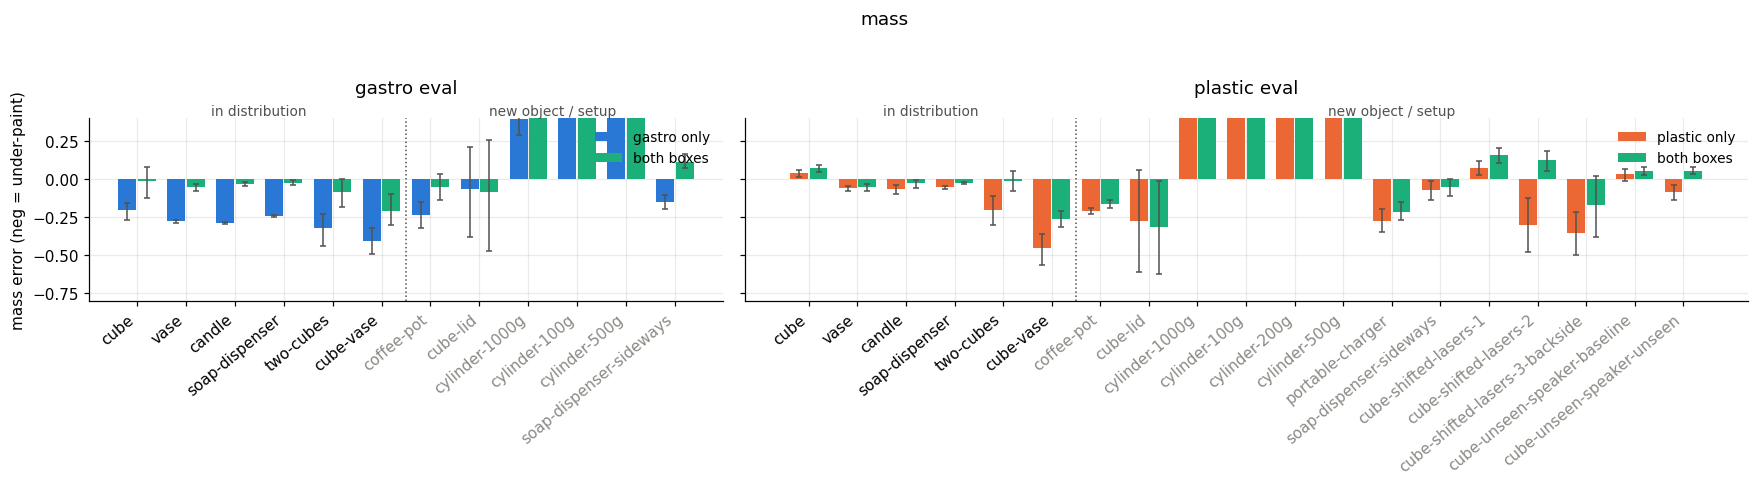

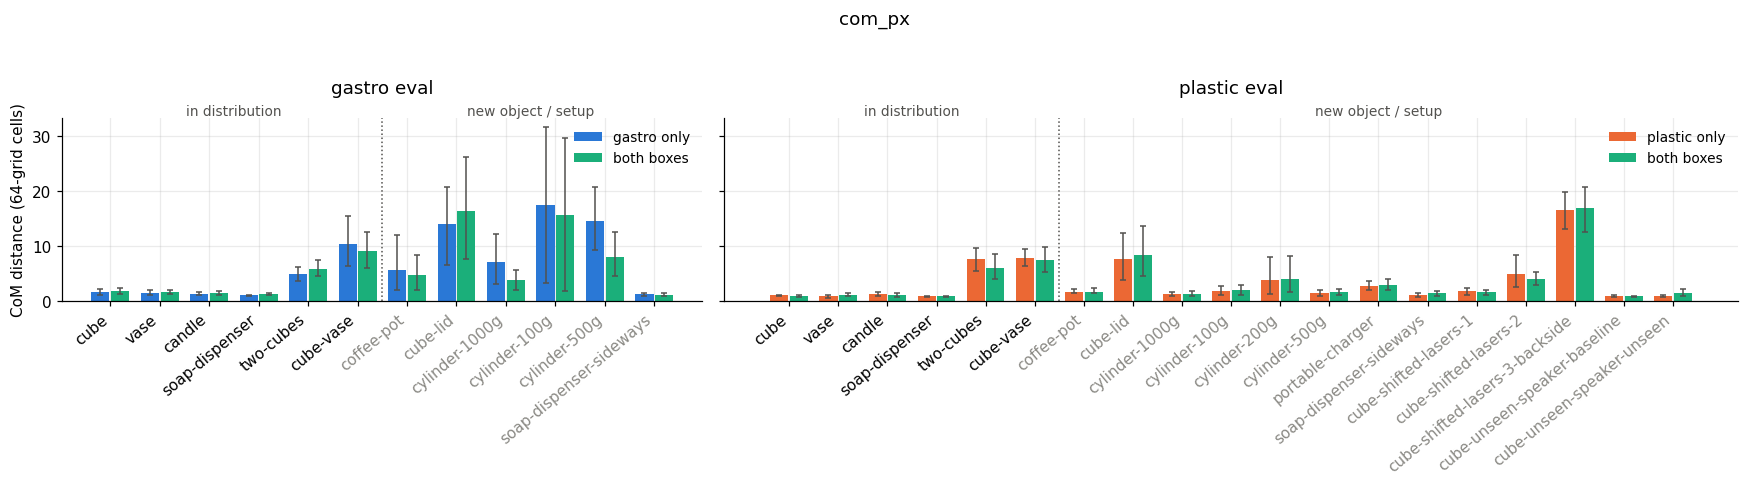

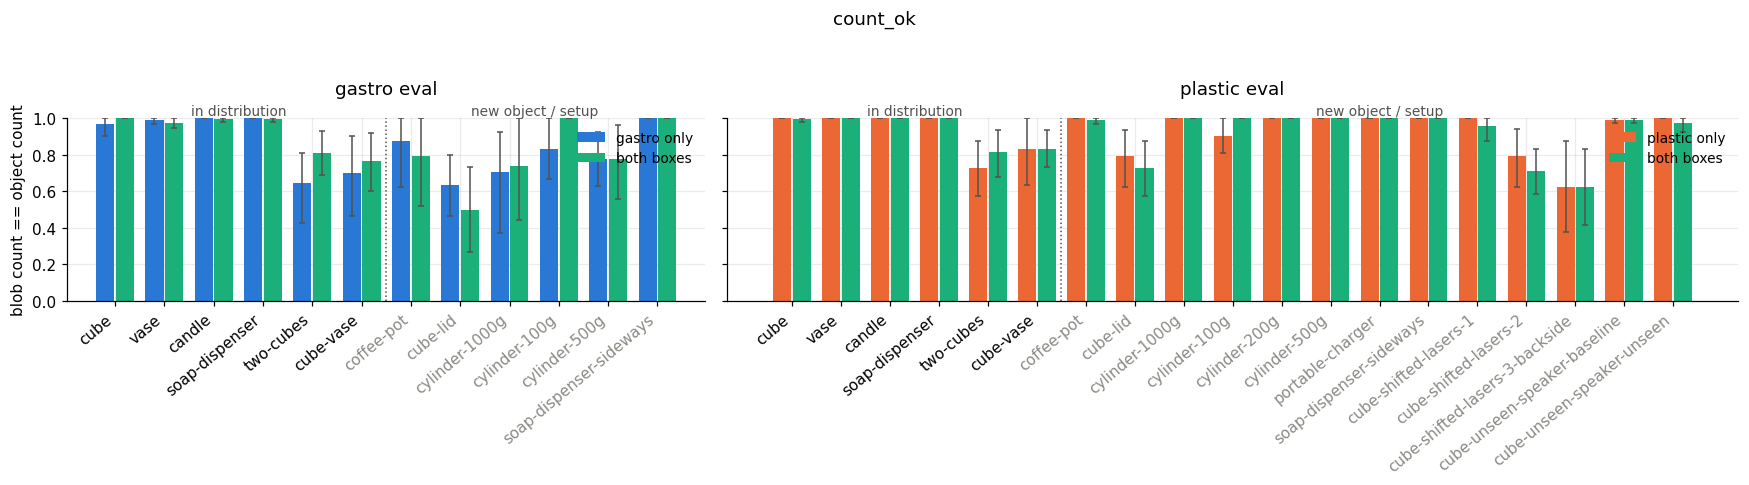

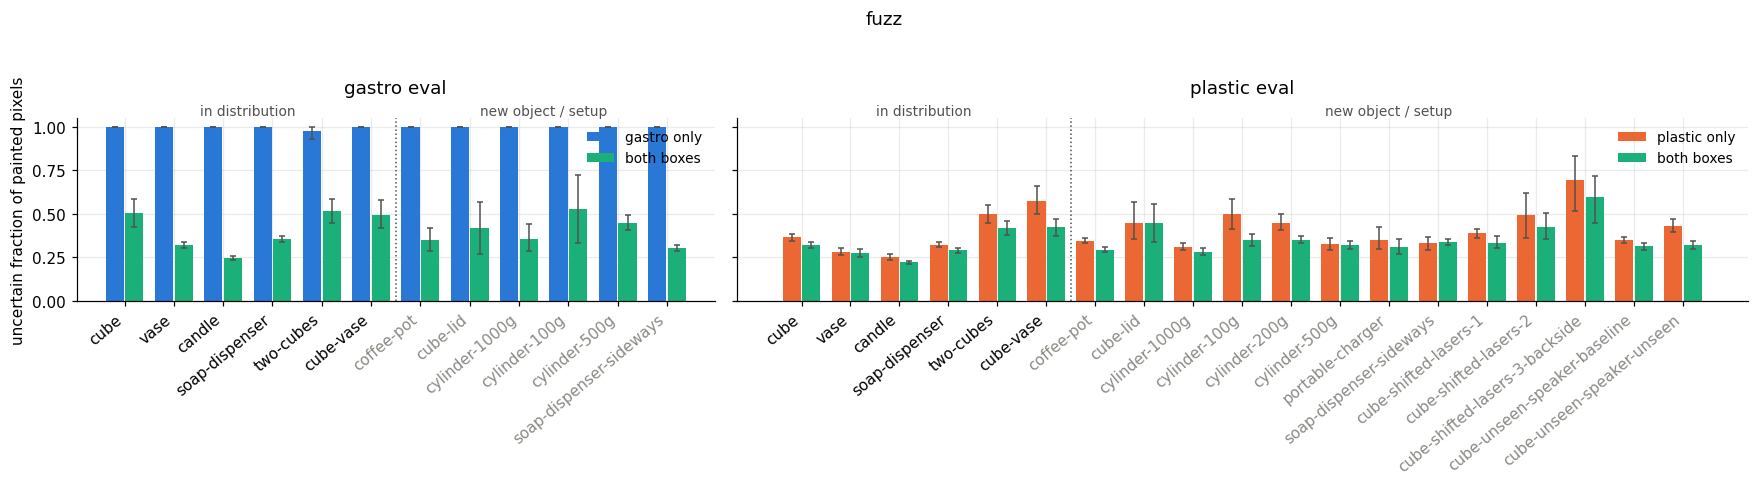

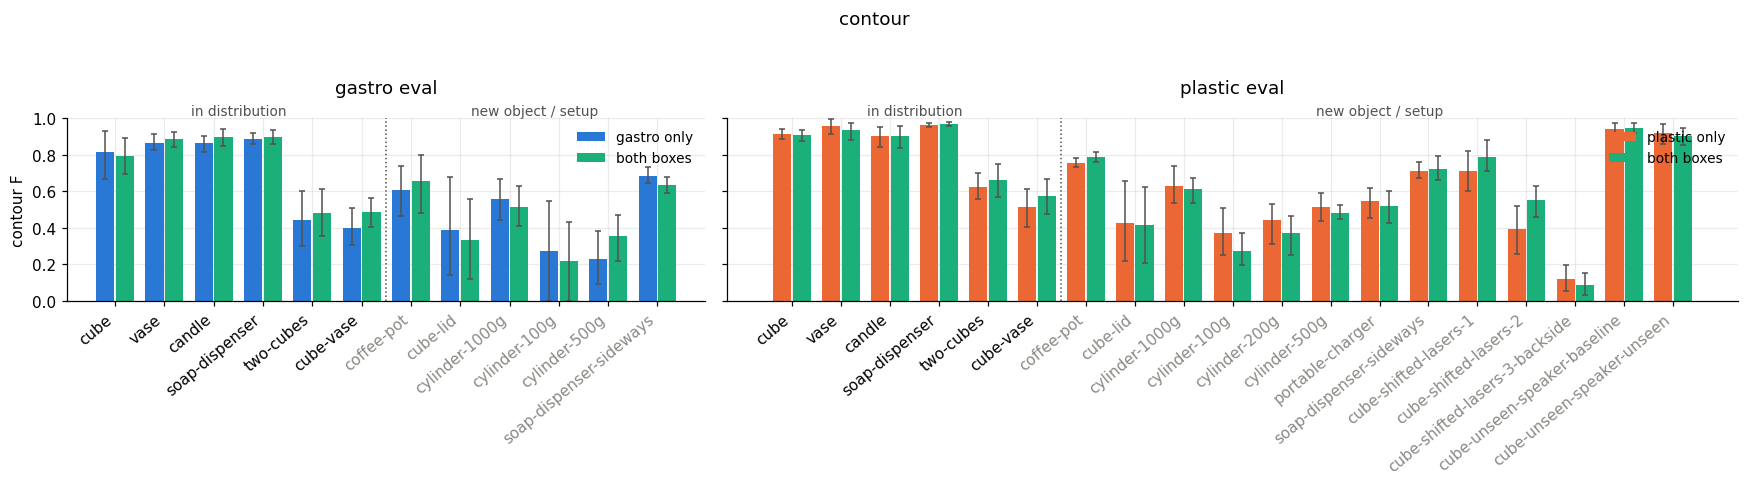

In [10]:
for metric, label, lim in [("mass", "mass error (neg = under-paint)", (-0.8, 0.4)), ("com_px", "CoM distance (64-grid cells)", None),
                           ("count_ok", "blob count == object count", (0, 1)), ("fuzz", "uncertain fraction of painted pixels", None),
                           ("contour", "contour F", (0, 1))]:
    split_bars(metric, ylabel=label, ylim=lim, title=metric)

In [11]:
summary = pd.concat({m: by_kind(m)[["single", "both"]] for m in ["iou", "mass", "com_px", "count_ok", "fuzz", "contour", "peak"]}, axis=1)
summary.round(3)

iou          mass        com_px        count_ok          fuzz        contour          peak       
arm                 single   both single   both single   both   single   both single   both  single   both single   both
box     kind                                                                                                            
gastro  ID           0.341  0.505 -0.290 -0.071  3.437  3.496    0.883  0.923  0.996  0.405   0.712  0.739  0.528  0.997
        OOD-object   0.184  0.262  0.215  0.305  9.992  8.308    0.804  0.802  1.000  0.400   0.456  0.451  0.525  0.962
plastic ID           0.591  0.622 -0.134 -0.053  3.205  2.891    0.927  0.940  0.382  0.324   0.810  0.823  0.995  1.000
        OOD-object   0.319  0.312  0.215  0.250  2.645  2.879    0.962  0.965  0.382  0.336   0.549  0.522  0.976  0.975
        OOD-setup    0.252  0.311 -0.195  0.035  7.702  7.504    0.806  0.764  0.525  0.452   0.408  0.475  0.874  0.943
        OOD-speaker  0.677  0.686 -0.028  0.053  0.848  1.086    0.996  0.983  0.387  0.316   0.931  0.925  0.990  1.000

## 6.1 Object count, in detail

Rows are the true object count, columns the number of blobs in the prediction. Under-counting a two-object sample (2 -> 1) and fragmenting a one-object sample (1 -> 2+) are different failures.

In [12]:
c = cmp.assign(arm=cmp.arm.where(~cmp.arm.isin(["gastro", "plastic"]), "single"), n_pred=cmp.n_pred.clip(upper=3))
c = c[c.arm.isin(["single", "both"])]
pd.crosstab([c.box, c.arm, c.n_true], c.n_pred, normalize="index").round(2).rename(columns={3: "3+"})

n_pred                    0     1     2    3+
box     arm    n_true                        
gastro  both   1       0.01  0.94  0.05  0.00
               2       0.00  0.14  0.79  0.07
        single 1       0.01  0.95  0.04  0.00
               2       0.07  0.24  0.67  0.03
plastic both   1       0.01  0.97  0.02  0.00
               2       0.00  0.10  0.82  0.08
        single 1       0.01  0.98  0.01  0.00
               2       0.00  0.22  0.77  0.01

# 7 Per-Sample: Uniform Shift or a Few Disasters?

A mean drop can come from every sample getting a bit worse or from a handful collapsing. The scatter puts each shared sample's single-box IoU on x and its `both` IoU on y. The histogram shows the paired differences.

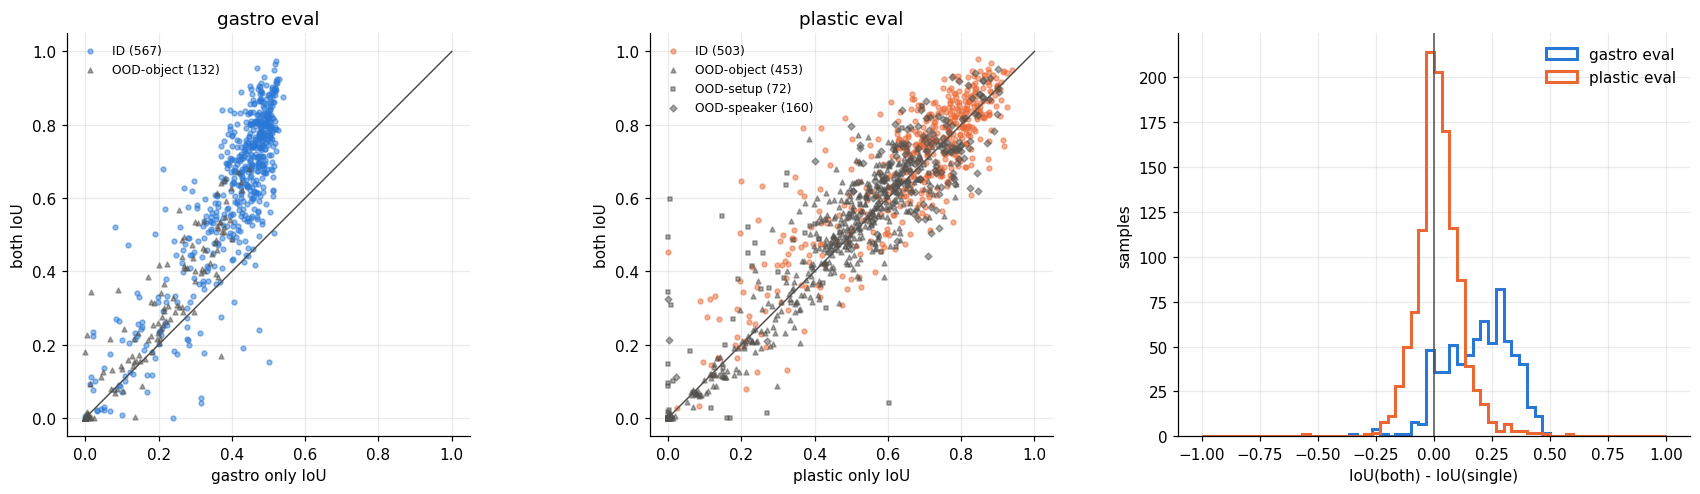

win_rate  loss_rate  median   mean    p10
box     kind                                                  
gastro  ID              0.912      0.046   0.241  0.218  0.031
        OOD-object      0.689      0.038   0.068  0.085 -0.002
plastic ID              0.529      0.310   0.027  0.028 -0.095
        OOD-object      0.397      0.278   0.005  0.014 -0.068
        OOD-setup       0.500      0.208   0.028  0.059 -0.111
        OOD-speaker     0.462      0.356   0.015  0.011 -0.121

In [13]:
pair = cmp[cmp.arm.isin(["gastro", "plastic", "both"])].assign(arm=lambda d: d.arm.where(d.arm == "both", "single"))
pair = pair.pivot_table(index=keys + ["kind"], columns="arm", values="iou").reset_index().dropna()
pair["d"] = pair.both - pair.single

fig, axes = plt.subplots(1, 3, figsize=(16, 4.6))
for ax, box in zip(axes[:2], EXPS):
    p = pair[pair.box == box]
    for k, mk in [("ID", "o"), ("OOD-object", "^"), ("OOD-setup", "s"), ("OOD-speaker", "D")]:
        q = p[p.kind == k]
        if len(q): ax.scatter(q.single, q.both, s=10, marker=mk, alpha=0.5, color=COLOR[box] if k == "ID" else "#52514e", label=f"{k} ({len(q)})")
    ax.plot([0, 1], [0, 1], color="#52514e", lw=1)
    ax.set_xlabel(f"{box} only IoU"); ax.set_ylabel("both IoU"); ax.set_title(f"{box} eval"); ax.legend(frameon=False, fontsize=8)
    ax.set_aspect("equal")
for box in EXPS:
    axes[2].hist(pair[pair.box == box].d, bins=np.linspace(-1, 1, 61), histtype="step", lw=2, color=COLOR[box], label=f"{box} eval")
axes[2].axvline(0, color="#52514e", lw=1)
axes[2].set_xlabel("IoU(both) - IoU(single)"); axes[2].set_ylabel("samples"); axes[2].legend(frameon=False)
fig.tight_layout(); plt.show()

pair.groupby(["box", "kind"]).d.agg(win_rate=lambda v: (v > 0.02).mean(), loss_rate=lambda v: (v < -0.02).mean(),
                                    median="median", mean="mean", p10=lambda v: v.quantile(0.1)).round(3)

# 8 Training Dynamics

Eval IoU vs epoch from the run logs (all speakers each run evaluated, so the levels differ slightly from the shared-sample numbers above). The x axis is epochs, i.e. times each sample has been seen. The dotted lines mark where `gastro` and `plastic` stopped.

In [14]:
PAT = re.compile(r"^\[metric\]\[batch=(\d+)\]: metrics/(eval|train)/?(.*)/(\w+): ([-\d.eE+na]+)")

def parse_log(key):
    out = []
    for line in open(REPO / "runs" / RUNS[key] / "logs-rank0.txt"):
        if line.startswith("[metric]") and (m := PAT.match(line)):
            out.append((int(m[1]), m[2], m[3], m[4], float(m[5])))
    df = pd.DataFrame(out, columns=["batch", "phase", "label", "metric", "value"]).drop_duplicates(["batch", "phase", "label", "metric"], keep="last")
    df["run"] = key
    return df

logs = pd.concat([parse_log(k) for k in RUNS], ignore_index=True)
BPE = {k: logs[logs.run == k].batch.max() / {"gastro": 500, "plastic": 1000}[k] for k in ("gastro", "plastic")}
BPE["both"] = 5  # 5664 samples / 1024, drop_last
logs["epoch"] = logs.batch / logs.run.map(BPE)
parts = logs[logs.phase == "eval"].label.str.extract(r"^(?:(gastro|plastic)/)?(.+)$")
logs.loc[logs.phase == "eval", "box"] = parts[0].fillna(logs.run).to_numpy()
logs.loc[logs.phase == "eval", "split"] = parts[1].replace(RENAME).to_numpy()
print({k: round(v, 2) for k, v in BPE.items()})

{'gastro': np.float64(4.0), 'plastic': np.float64(3.0), 'both': 5}


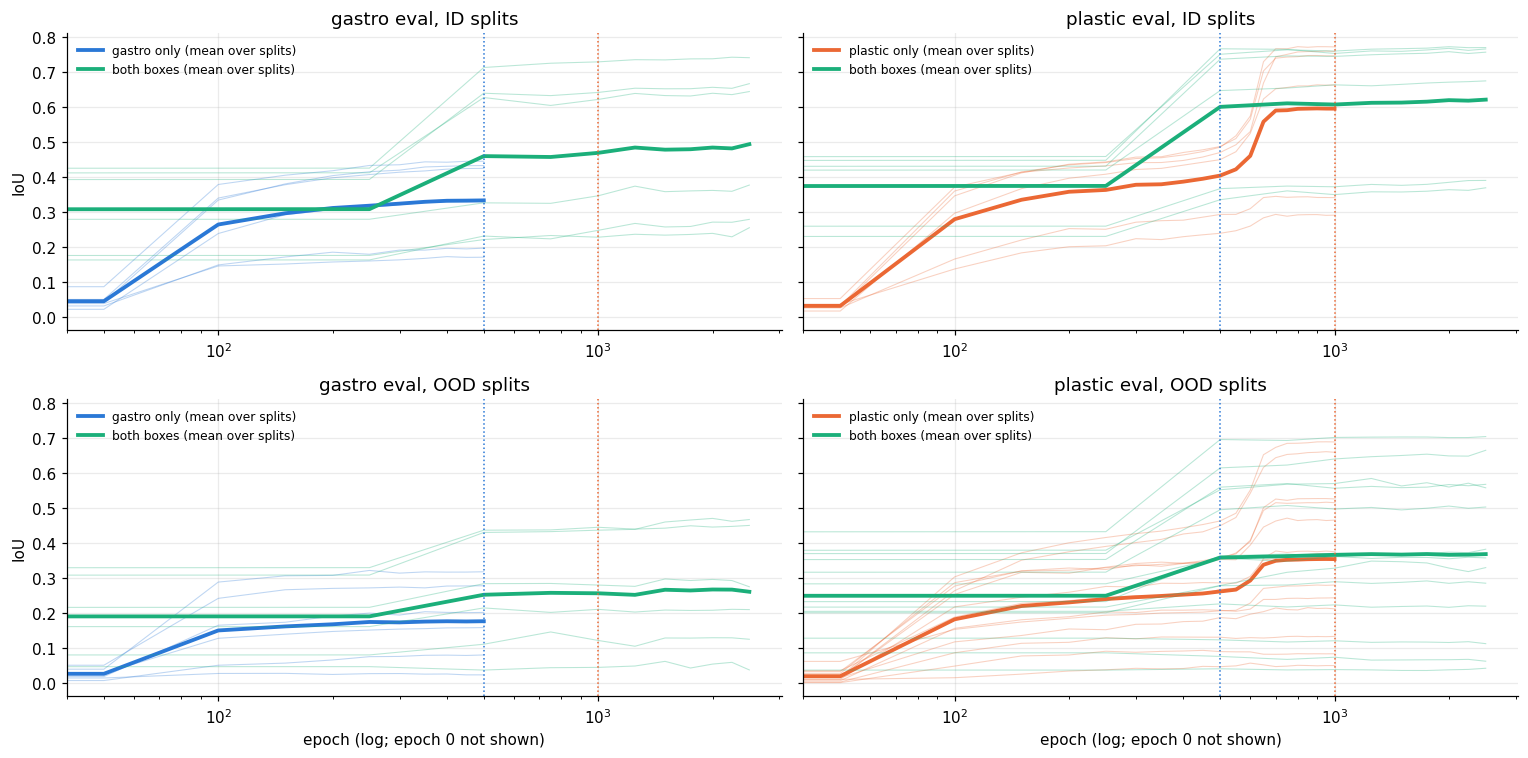

In [15]:
ev = logs[(logs.phase == "eval") & (logs.metric == "iou") & logs.box.isin(list(EXPS))]
fig, axes = plt.subplots(2, 2, figsize=(14, 7), sharey=True)
for col, box in enumerate(EXPS):
    for row, k in enumerate(["ID", "OOD"]):
        ax = axes[row, col]
        for key in (box, "both"):
            e = ev[(ev.run == key) & (ev.box == box) & ev.split.isin(SPLITS[box])]
            e = e[e.split.map(kind).eq("ID") == (k == "ID")]
            m = e.groupby(["epoch", "split"]).value.mean().unstack()
            for s in m: ax.plot(m.index, m[s], color=COLOR[key], lw=0.7, alpha=0.3)
            ax.plot(m.index, m.mean(axis=1), color=COLOR[key], lw=2.5, label=f"{LABEL[key]} (mean over splits)")
        for key in ("gastro", "plastic"):
            ax.axvline({"gastro": 500, "plastic": 1000}[key], color=COLOR[key], ls=":", lw=1)
        ax.set_xscale("log"); ax.set_xlim(40, None); ax.set_title(f"{box} eval, {k} splits"); ax.legend(frameon=False, fontsize=8)
for ax in axes[-1]: ax.set_xlabel("epoch (log; epoch 0 not shown)")
for ax in axes[:, 0]: ax.set_ylabel("IoU")
fig.tight_layout(); plt.show()

## 8.1 Fit vs generalization

Is `both` under-fitting (it has twice as many distinct targets to memorise with the same network), or fitting fine and generalizing worse? Train IoU is the composer train metric over the last epoch.

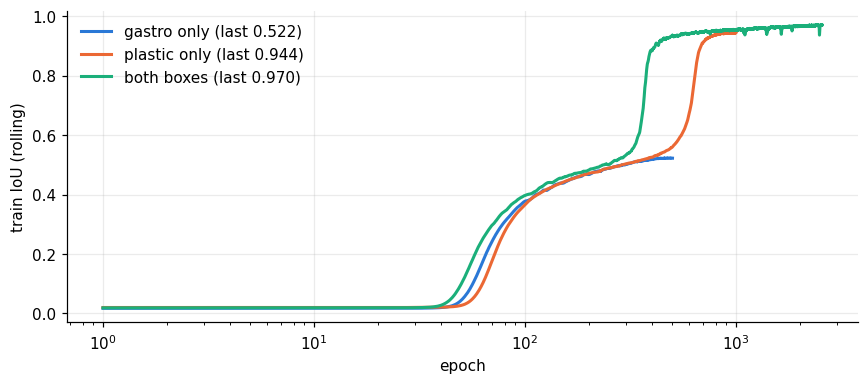

In [16]:
tr = logs[(logs.phase == "train") & (logs.metric == "iou") & (logs.label == "")]
last = tr.sort_values("batch").groupby("run").tail(BPE["both"] * 5).groupby("run").value.mean()
fig, ax = plt.subplots(figsize=(8, 3.6))
for key in RUNS:
    t_ = tr[tr.run == key].sort_values("epoch")
    t_ = t_[t_.epoch >= 1]
    ax.plot(t_.epoch, t_.value.rolling(20, min_periods=1).mean(), color=COLOR[key], lw=2, label=f"{LABEL[key]} (last {last[key]:.3f})")
ax.set_xscale("log"); ax.set_ylabel("train IoU (rolling)"); ax.set_xlabel("epoch"); ax.legend(frameon=False)
fig.tight_layout(); plt.show()

# 9 Aux Heads: Class, Count, Position, Area

The heads (object class, object count, CoM, log area) are not saved per sample, so these come from the logged per-split numbers at each run's last eval. They include every speaker the run evaluated, so treat small differences with care.

`cls_acc` and `cls_conf` only count known classes; on new objects `cls_conf` is the OOD signal (lower is better there: the model should be less sure).

In [17]:
HEAD = ["cls_acc", "cls_conf", "count_mae", "com_px", "area_rel_err"]
lastev = logs[(logs.phase == "eval") & logs.metric.isin(HEAD) & logs.box.isin(list(EXPS))]
lastev = lastev[lastev.batch == lastev.groupby("run").batch.transform("max")]
lastev = lastev.assign(arm=lastev.run.where(lastev.run == "both", "single"), kind=lastev.split.map(kind))
heads = lastev.pivot_table(index=["box", "kind", "split"], columns=["metric", "arm"], values="value")
heads = heads.loc[[i for i in heads.index if i[2] in SPLITS[i[0]]]]
heads.round(3)

metric                                             area_rel_err        cls_acc        cls_conf         com_px         count_mae       
arm                                                        both single    both single     both single    both  single      both single
box     kind        split                                                                                                             
gastro  ID          candle                                0.071  0.105   1.000  1.000    1.000  0.999   1.302   1.453     0.000  0.000
                    cube                                  0.090  0.109   0.959  1.000    0.981  0.994   3.225   2.157     0.000  0.000
                    cube-vase                             0.241  0.213   0.700  0.840    0.974  0.884   4.323   5.391     0.000  0.000
                    soap-dispenser                        0.050  0.064   1.000  1.000    0.999  0.997   1.075   1.342     0.000  0.000
                    two-cubes                             0.112  0.123   0.905  0.929    0.950  0.932   6.174   6.778     0.024  0.000
                    vase                                  0.072  0.094   0.982  1.000    0.992  0.987   1.822   2.094     0.000  0.000
        OOD-object  coffee-pot                            0.184  0.333     NaN    NaN    0.846  0.778   5.768   5.626     0.125  0.133
                    cube-lid                              1.025  1.071   0.133  0.420    0.872  0.788  14.730  14.164     0.233  0.120
                    cylinder-1000g                        2.463  2.609     NaN    NaN    0.880  0.725   5.943   6.305     0.111  0.133
                    cylinder-100g                         1.401  2.446     NaN    NaN    0.926  0.748  19.635  19.795     0.667  0.400
                    cylinder-500g                         3.365  3.365     NaN    NaN    0.905  0.811  10.662   9.186     0.074  0.133
                    soap-dispenser-sideways               0.234  0.199   1.000  1.000    0.970  0.976   1.705   2.783     0.000  0.000
plastic ID          candle                                0.104  0.193   0.987  0.990    0.995  0.988   1.722   2.065     0.000  0.000
                    cube                                  0.169  0.152   0.973  0.950    0.983  0.950   1.437   1.990     0.000  0.000
                    cube-vase                             0.394  0.508   0.367  0.450    0.896  0.819   6.145   6.331     0.067  0.150
                    soap-dispenser                        0.053  0.098   1.000  0.996    1.000  0.996   1.181   1.614     0.000  0.000
                    two-cubes                             0.123  0.216   0.521  0.625    0.940  0.810   6.197   6.876     0.062  0.125
                    vase                                  0.064  0.141   1.000  0.986    0.995  0.990   1.078   1.473     0.000  0.000
        OOD-object  coffee-pot                            0.281  0.389     NaN    NaN    0.977  0.918   2.122   2.913     0.000  0.005
                    cube-lid                              1.481  0.918   0.292  0.125    0.890  0.742   3.876   4.360     0.083  0.266
                    cylinder-1000g                        1.934  1.654     NaN    NaN    0.984  0.950   1.082   1.372     0.000  0.000
                    cylinder-100g                         7.990  7.471     NaN    NaN    0.977  0.965   5.746   6.690     0.000  0.000
                    cylinder-200g                         5.083  4.268     NaN    NaN    0.974  0.952   6.717   7.836     0.000  0.000
                    cylinder-500g                         3.228  2.461     NaN    NaN    0.999  0.985   2.426   3.406     0.000  0.000
                    portable-charger                      0.410  0.502     NaN    NaN    0.898  0.789   2.804   3.296     0.000  0.000
                    soap-dispenser-sideways               0.113  0.216   1.000  1.000    1.000  0.973   2.006   2.242     0.000  0.000
        OOD-setup   cube-shifted-lasers-1                 0.581  0.246   0.625  0.531

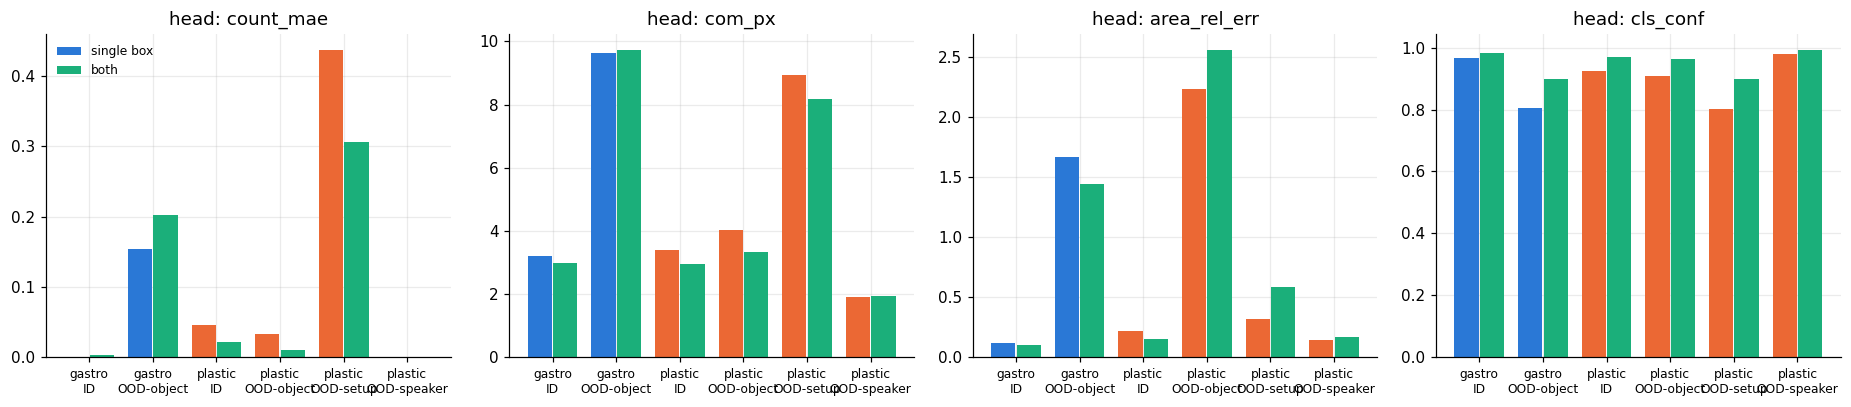

In [18]:
fig, axes = plt.subplots(1, 4, figsize=(17, 3.8))
for ax, metric in zip(axes, ["count_mae", "com_px", "area_rel_err", "cls_conf"]):
    h = heads[metric].groupby(level=["box", "kind"]).mean()
    x = np.arange(len(h))
    ax.bar(x - 0.2, h.single, 0.38, color=[COLOR[b] for b, _ in h.index], label="single box")
    ax.bar(x + 0.2, h.both, 0.38, color=COLOR["both"], label="both")
    ax.set_xticks(x, [f"{b}\n{k}" for b, k in h.index], fontsize=8)
    ax.set_title(f"head: {metric}")
axes[0].legend(frameon=False, fontsize=8)
fig.tight_layout(); plt.show()

# 10 Weights

Does the two-box model grow bigger weights? RMS of every trainable tensor (no BN running stats), grouped by module. AdamW weight decay plus a cosine schedule means weight size depends a lot on *where in the schedule* a checkpoint sits, so the table lists every checkpoint with its epoch and fraction of the schedule completed.

In [19]:
def ckpts(key):
    for f in sorted((REPO / "runs" / RUNS[key] / "checkpoints").glob("ep*-rank0.pt")):
        yield int(f.name[2:].split("-")[0]), f

TOTAL = {"gastro": 500, "plastic": 1000, "both": 5000}
def group(name):
    p = name.split(".")
    if p[0] == "encoder": return f"encoder.{p[1]}"
    if p[0] == "decoder": return "decoder.project" if p[1] == "project" else "decoder.stages"
    return p[0].replace("_head", "") + " (head)" if "head" in p[0] else p[0]

wrows = []
for key in RUNS:
    for ep, f in ckpts(key):
        sd = torch.load(f, map_location="cpu", weights_only=False)["state"]["model"]
        for name, v in sd.items():
            if not v.is_floating_point() or "running_" in name or name == "cls_weight": continue
            wrows.append(dict(run=key, epoch=ep, frac=ep / TOTAL[key], group=group(name), sq=float((v.float() ** 2).sum()), n=v.numel(),
                              absmax=float(v.abs().max())))
w = pd.DataFrame(wrows)
wg = w.groupby(["run", "epoch", "frac", "group"]).agg(sq=("sq", "sum"), n=("n", "sum"), absmax=("absmax", "max")).reset_index()
wg["rms"] = np.sqrt(wg.sq / wg.n)
tot = w.groupby(["run", "epoch", "frac"]).agg(sq=("sq", "sum"), n=("n", "sum")).reset_index().assign(rms=lambda d: np.sqrt(d.sq / d.n), l2=lambda d: np.sqrt(d.sq))
print(tot[["run", "epoch", "frac", "rms", "l2"]].round(4).to_string(index=False))
wg.pivot_table(index="group", columns=["run", "epoch"], values="rms").round(4)

    run  epoch  frac    rms       l2
   both   1000  0.20 0.0171  99.5949
   both   2000  0.40 0.0173 100.8425
 gastro    250  0.50 0.0169  98.5847
 gastro    500  1.00 0.0169  98.6142
plastic    250  0.25 0.0169  98.5094
plastic    500  0.50 0.0169  98.6090
plastic    750  0.75 0.0169  98.6776
plastic   1000  1.00 0.0169  98.6811


run                both          gastro         plastic                        
epoch              1000    2000    250     500     250     500     750     1000
group                                                                          
area (head)      0.0182  0.0183  0.0181  0.0181  0.0181  0.0181  0.0181  0.0181
cls (head)       0.0193  0.0198  0.0185  0.0186  0.0185  0.0186  0.0187  0.0187
com (head)       0.0181  0.0183  0.0181  0.0181  0.0180  0.0180  0.0180  0.0180
count (head)     0.0186  0.0189  0.0183  0.0183  0.0182  0.0183  0.0183  0.0183
decoder.project  0.0183  0.0185  0.0181  0.0181  0.0181  0.0181  0.0181  0.0181
decoder.stages   0.0161  0.0164  0.0158  0.0158  0.0158  0.0158  0.0159  0.0159
empty (head)     0.0180  0.0179  0.0180  0.0180  0.0181  0.0180  0.0180  0.0180
encoder.freq     0.0543  0.0541  0.0544  0.0544  0.0544  0.0543  0.0543  0.0543
encoder.grid     0.0151  0.0152  0.0149  0.0150  0.0149  0.0150  0.0150  0.0150

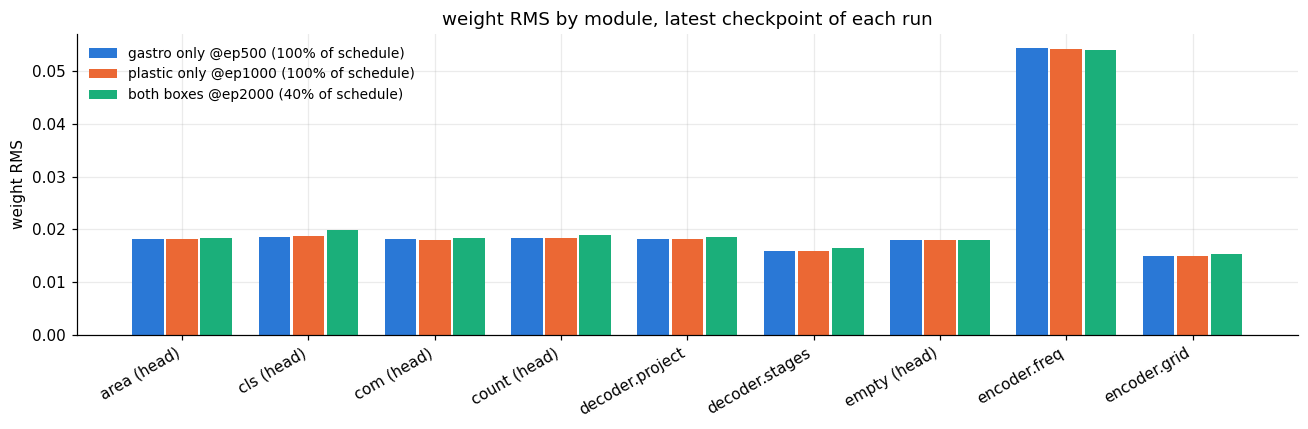

In [20]:
fig, ax = plt.subplots(figsize=(12, 4))
final = wg[wg.epoch == wg.groupby("run").epoch.transform("max")]
groups = sorted(final.group.unique())
for j, key in enumerate(RUNS):
    f = final[final.run == key].set_index("group").reindex(groups)
    ax.bar(np.arange(len(groups)) + (j - 1) * 0.27, f.rms, 0.25, color=COLOR[key],
           label=f"{LABEL[key]} @ep{final[final.run == key].epoch.iloc[0]} ({final[final.run == key].frac.iloc[0]:.0%} of schedule)")
ax.set_xticks(range(len(groups)), groups, rotation=30, ha="right"); ax.set_ylabel("weight RMS"); ax.legend(frameon=False, fontsize=9)
ax.set_title("weight RMS by module, latest checkpoint of each run")
fig.tight_layout(); plt.show()

# 11 Where It Hurts Most

The shared samples with the biggest IoU drop, single-box prediction next to `both`. Rows are the 6 worst per box.

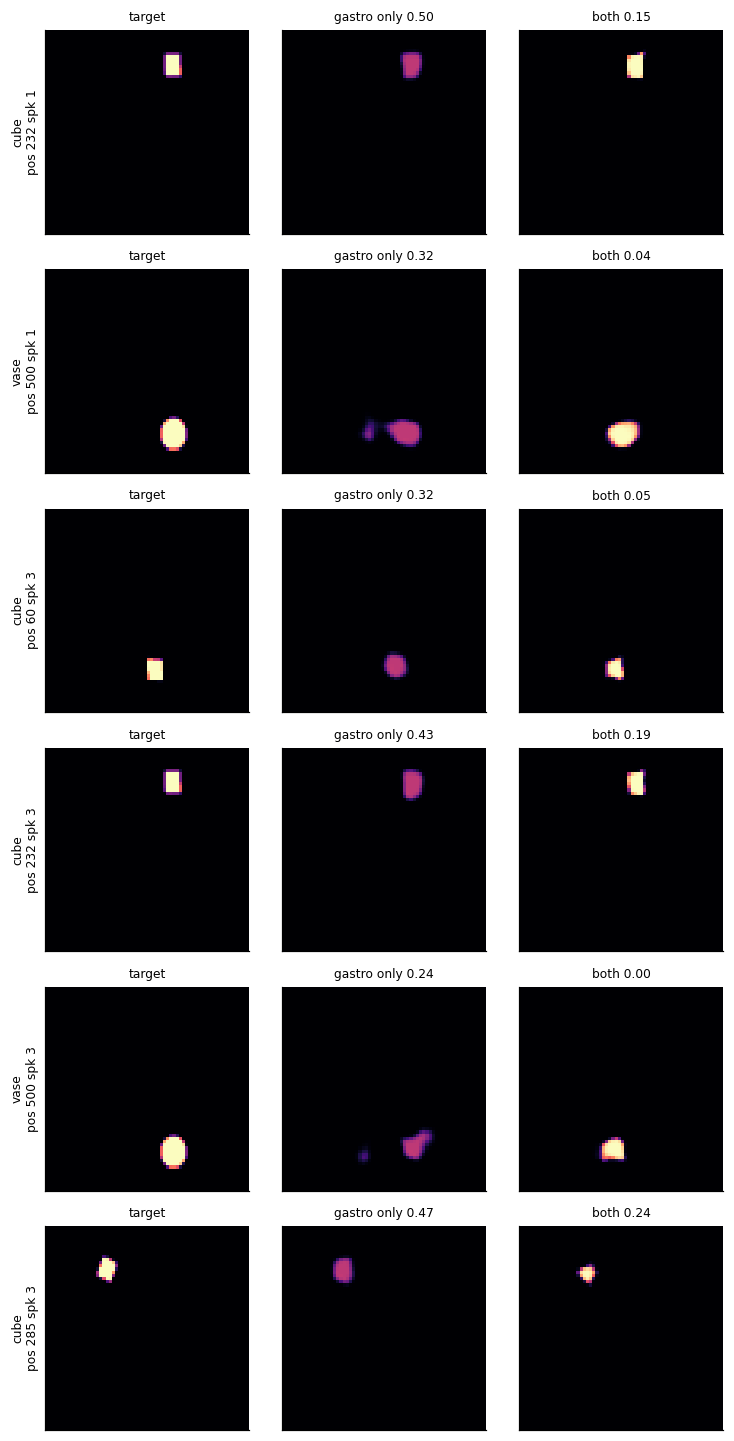

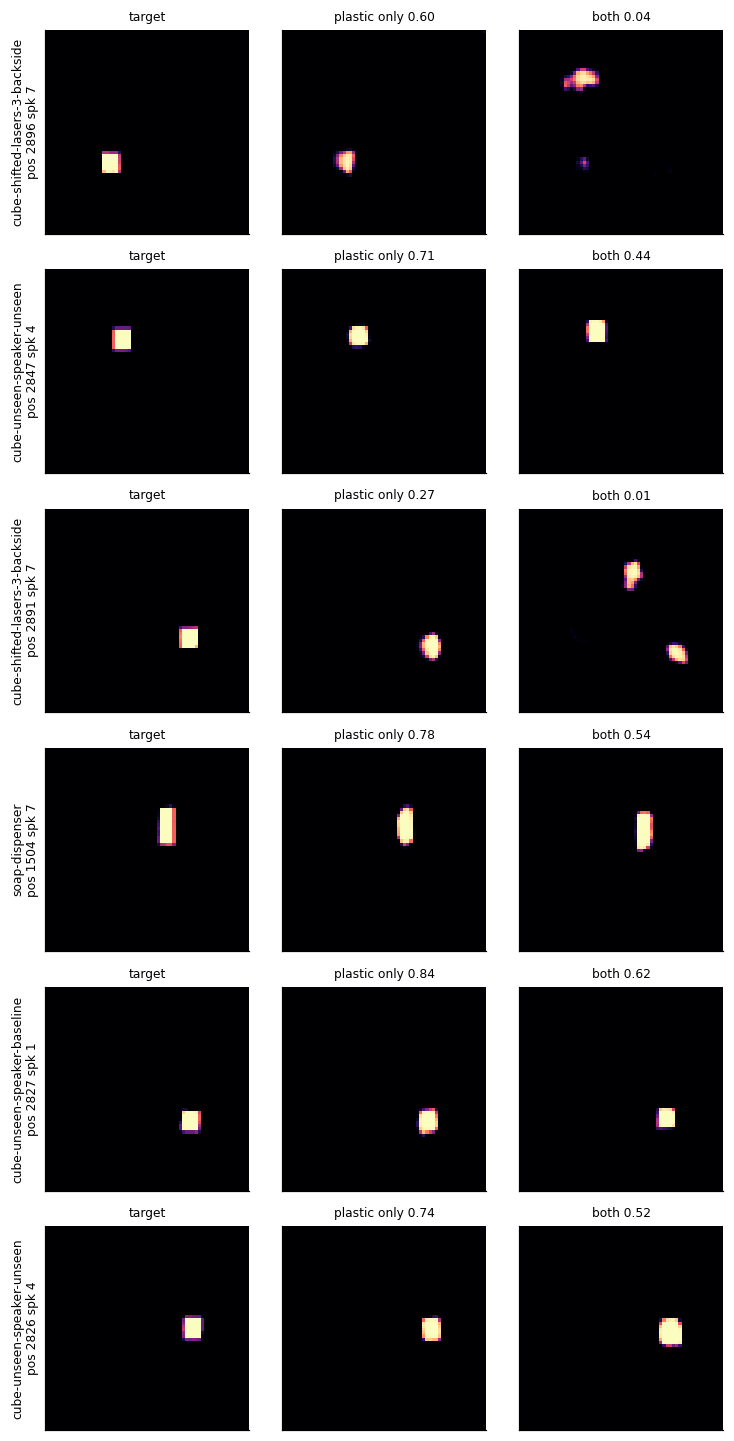

In [21]:
def show_worst(box, k=6):
    worst = pair[pair.box == box].nsmallest(k, "d")
    gt = GT[box]
    fig, axes = plt.subplots(k, 3, figsize=(7, 2.2 * k))
    for r, (_, row) in enumerate(worst.iterrows()):
        sid = cmp[(cmp.box == box) & (cmp.position_id == row.position_id) & (cmp.speaker == row.speaker)].sid.iloc[0]
        ims = [gt.masks[gt.row_of[sid]], MASKS[(box, box, sid)], MASKS[("both", box, sid)]]
        for c, (im, title) in enumerate(zip(ims, ["target", f"{box} only {row.single:.2f}", f"both {row.both:.2f}"])):
            axes[r, c].imshow(np.asarray(im, dtype=np.float32), vmin=0, vmax=1, cmap="magma")
            axes[r, c].set_xticks([]); axes[r, c].set_yticks([]); axes[r, c].grid(False)
            axes[r, c].set_title(title if r == 0 or c else title, fontsize=8)
        axes[r, 0].set_ylabel(f"{row.split}\npos {row.position_id} spk {row.speaker}", fontsize=8)
    fig.tight_layout(); plt.show()

for box in EXPS: show_worst(box)

# 12 Takeaways

Written against `both` at ep2500 of 5000 (still training, mid-schedule). Re-run once `gastro-plastic-bb-v3` finishes: `LATEST` picks up its last epoch automatically, and the numbers below will move.

**1. Training on both boxes costs little, and it does so with much less data per box.** Against the fair baselines, `both` is **+0.031 IoU on plastic ID splits** and **-0.038 on gastro ID splits** (vs `fo-base-v1` at 32x32). On new objects it is flat on both boxes (plastic -0.007, gastro -0.003). That is with only speakers 1,3,7: 25% fewer plastic samples and 42% fewer gastro samples than the single-box runs. The two-box penalty is small at worst, and part of it is probably the missing data, not the second box.

**2. The losses are object-specific, not across the board.** On gastro the drop comes from the cube splits: cube -0.07, two-cubes -0.07, cube-vase -0.04. Candle and soap dispenser hold (-0.02, -0.01). Gastro cube is also the one object where `both` trained on fewer *positions* (197 vs 225), because the combined split holds 35 cube positions out for the unseen-speaker test. On plastic, vase is the only ID split that got worse (-0.04, 9 positions). The other five improved, two-cubes and cube-vase the most (+0.06, +0.08).

**3. No in-distribution vs out-of-distribution split in the effect, except the shifted lasers.** New objects (cylinders, cube lid, coffee pot, charger) barely move on either box, and plastic cylinders lose about 0.02. The unseen speaker is flat (+0.01). The one OOD gain is the **shifted-laser cubes: +0.06** (+0.09 and +0.11 on lasers-1 and -2, -0.02 on the backside). Seeing two boxes with different laser geometry seems to make the model a little more robust to a moved laser grid. These are 8-position splits, so this needs a second seed.

**4. Not more confused. The masks are sharper, but the model is more over-confident on unknown objects.** On plastic, `both` paints more firmly (uncertain-pixel fraction 0.32 vs 0.38), under-paints less (mass -0.05 vs -0.13), and counts two-object scenes better (82% vs 77% exact, merges fall from 22% to 10%). It does fragment more (8% of two-object samples get 3+ blobs vs 1%). The count, CoM and area heads all improve on plastic. The catch is the class head: on objects it never saw, `cls_conf` rises (plastic new objects 0.97 vs 0.93, shifted lasers 0.90 vs 0.80). That makes the "this is something new" signal **worse**.

**5. The weights are essentially the same size, and the comparison has three open confounds.** Weight RMS is 0.0173 vs 0.0169 (+2%). Most of that is the class head (+6%), and every module is within a few percent, so there is no "bigger weights" story. Fix these before trusting the gastro numbers: (a) **the 64x64 gastro-only run stopped before its jump**. The plastic run sat on a plateau until ~ep700 and then jumped from 0.40 to 0.60 (section 8), and gastro stopped at ep500 still on its plateau. Re-run it for >= 1000 ep. (b) **Speakers differ** (5 / 4 / 3). Train the single-box runs on speakers 1,3,7 too, or the combined run on all of them. (c) **Neither single-box model has been run on the other box**, so cross-box transfer (the third bar per split) is still unmeasured.

In [22]:
print("IoU by kind (shared samples):"); print(by_kind("iou").round(3))
print("\npaired IoU change:"); print(pair.groupby(["box", "kind"]).d.agg(["mean", "median", lambda v: (v < -0.02).mean()]).round(3))
print("\nother metrics:"); print(summary.round(3))

IoU by kind (shared samples):
arm                  single  both@500  both@1000   both
box     kind                                           
gastro  ID            0.341     0.464      0.476  0.505
        OOD-object    0.184     0.253      0.258  0.262
plastic ID            0.591     0.599      0.603  0.622
        OOD-object    0.319     0.311      0.312  0.312
        OOD-setup     0.252     0.292      0.313  0.311
        OOD-speaker   0.677     0.656      0.672  0.686

paired IoU change:
                      mean  median  <lambda_0>
box     kind                                  
gastro  ID           0.218   0.241       0.046
        OOD-object   0.085   0.068       0.038
plastic ID           0.028   0.027       0.310
        OOD-object   0.014   0.005       0.278
        OOD-setup    0.059   0.028       0.208
        OOD-speaker  0.011   0.015       0.356

other metrics:
                       iou          mass        com_px        count_ok          fuzz        contour          p